# Risk Parity - Long Only Strategy

This notebook demonstrates a long-only risk parity strategy using A-Stock ETFs with pysystemtrade.

**Instruments:**
- 510300.SH: Huatai-PB CSI 300 ETF (Equity)
- 518880.SH: Gold ETF (Commodity)
- 511260.SH: SSE Corporate Bond ETF (Fixed Income)

**Risk parity achieved through:**
1. Rolling inverse-volatility weights: recalculated monthly using 63-day lookback
2. Trading rule: constant 10.0 forecast (long bias)
3. Vol scaling: positionSize stage divides notional by instrument volatility

In [1]:
# Change to project root directory
import os
from pathlib import Path

# Navigate from examples/ to project root
project_root = Path(os.getcwd()).parent
os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")

Working directory: c:\Users\rtru3\.kimaki\projects\pysystemtrade


In [2]:
# Setup: ensure target ETFs are in the universe

TARGET_ETFS = ["510300.SH", "518880.SH", "511260.SH"]

import pandas as pd
from pathlib import Path

# Check valid_symbols.csv
valid_symbols_path = Path("data/astock/csvconfig/valid_symbols.csv")
if valid_symbols_path.exists():
    valid_symbols = pd.read_csv(valid_symbols_path)
    if "Instrument" in valid_symbols.columns:
        existing = valid_symbols["Instrument"].tolist()
        missing = [e for e in TARGET_ETFS if e not in existing]
        if missing:
            print(f"Adding to valid_symbols.csv: {missing}")
            new_rows = pd.DataFrame({"Instrument": missing})
            valid_symbols = pd.concat([valid_symbols, new_rows], ignore_index=True)
            valid_symbols.to_csv(valid_symbols_path, index=False)
        else:
            print("All target ETFs already in valid_symbols.csv")
    else:
        print("Invalid format, recreating...")
        valid_symbols = pd.DataFrame({"Instrument": TARGET_ETFS})
        valid_symbols.to_csv(valid_symbols_path, index=False)
else:
    print("valid_symbols.csv not found, creating...")
    valid_symbols = pd.DataFrame({"Instrument": TARGET_ETFS})
    valid_symbols.to_csv(valid_symbols_path, index=False)

print(f"Target ETFs: {TARGET_ETFS}")

All target ETFs already in valid_symbols.csv
Target ETFs: ['510300.SH', '518880.SH', '511260.SH']


In [3]:
# Fetch data for target ETFs

import subprocess

# Check if parquet data exists for target ETFs
parquet_dir = Path("data/astock/daily_prices_parquet")
existing_files = list(parquet_dir.glob("*.parquet")) if parquet_dir.exists() else []

print(f"Existing parquet files: {len(existing_files)}")

# Fetch data using the fetcher (using --symbols for specific instruments)
print("Fetching data for target ETFs...")
print("This may take a few minutes...")

result = subprocess.run(
    ["python", "-m", "sysinit.astock.fetcher", "--symbols"] + TARGET_ETFS + ["--once", "--freq", "daily"],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print("Data fetch completed!")
    if result.stdout:
        print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
else:
    print(f"Error fetching data: {result.stderr}")
    print("You may need to set XIXIMIAO_TOKEN in your .env file")

Existing parquet files: 3
Fetching data for target ETFs...
This may take a few minutes...
Data fetch completed!


In [4]:
# Verify data is available

from sysdata.sim.astock_sim_data import AStockSimData

data = AStockSimData()
available = data.get_instrument_list()

print(f"Available instruments: {len(available)}")

for etf in TARGET_ETFS:
    if etf in available:
        prices = data.get_raw_price(etf)
        print(f"  {etf}: {len(prices)} rows, {prices.index[0].date()} to {prices.index[-1].date()}")
    else:
        print(f"  {etf}: NOT AVAILABLE")

Configuring sim logging
Available instruments: 3
  510300.SH: 1210 rows, 2021-03-29 to 2026-03-26
  518880.SH: 1210 rows, 2021-03-29 to 2026-03-26
  511260.SH: 1210 rows, 2021-03-29 to 2026-03-26


In [ ]:
# Calculate rolling risk parity weights (inverse volatility, monthly recalculation)

import pandas as pd
import numpy as np

# Parameters
vol_lookback = 63  # ~3 months of trading days for vol calculation
trading_days_per_year = 252

# Get price data for all instruments
price_dict = {}
for instr in TARGET_ETFS:
    price_dict[instr] = data.get_raw_price(instr)

# Calculate daily returns for all instruments
returns_dict = {}
for instr, prices in price_dict.items():
    returns_dict[instr] = prices.pct_change().dropna()

# Create a combined DataFrame of returns
returns_df = pd.DataFrame(returns_dict)
returns_df = returns_df.dropna()

# Function to calculate inverse-volatility weights
def calc_inv_vol_weights(vol_series_dict):
    inv_vols = {instr: 1/vol for instr, vol in vol_series_dict.items()}
    total = sum(inv_vols.values())
    return {instr: w/total for instr, w in inv_vols.items()}

# Calculate rolling volatility and weights
# We need to resample to monthly dates and calculate weights based on prior period vol

# Get all business days in our date range
all_dates = returns_df.index

# Group by year-month to get month ends
monthly_dates = all_dates.to_frame().set_index(all_dates.to_period('M').to_timestamp()).index.unique()

# For each month, calculate weights based on prior period's volatility
rolling_weights_list = []

for i, month_end in enumerate(monthly_dates):
    if i == 0:
        continue  # Skip first month (need lookback period)
    
    # Get lookback period (prior 3 months of data)
    lookback_start_idx = max(0, i - int(vol_lookback / 21))  # approximate
    lookback_start = monthly_dates[lookback_start_idx]
    
    # Get returns for the lookback period
    lookback_returns = returns_df.loc[lookback_start:month_end]
    
    if len(lookback_returns) < 20:  # Need minimum data points
        continue
    
    # Calculate annualized volatility for each instrument
    vol_dict = {}
    for instr in TARGET_ETFS:
        instr_returns = lookback_returns[instr].dropna()
        if len(instr_returns) > 0:
            ann_vol = instr_returns.std() * np.sqrt(trading_days_per_year)
            vol_dict[instr] = ann_vol
    
    if len(vol_dict) == len(TARGET_ETFS):  # All instruments have data
        weights = calc_inv_vol_weights(vol_dict)
        rolling_weights_list.append({
            'date': month_end,
            **weights
        })

# Create DataFrame of rolling weights
rolling_weights_df = pd.DataFrame(rolling_weights_list).set_index('date')

# Forward fill weights to get daily weights
daily_weights = rolling_weights_df.reindex(all_dates, method='ffill')
daily_weights = daily_weights.dropna()

print(f"Rolling weights calculated from {daily_weights.index[0].date()} to {daily_weights.index[-1].date()}")
print(f"Number of weight periods: {len(rolling_weights_df)}")
print(f"\nLatest weights:")
for instr in TARGET_ETFS:
    print(f"  {instr}: {rolling_weights_df[instr].iloc[-1]:.4f}")

# For comparison, calculate equal weights
equal_weight = 1.0 / len(TARGET_ETFS)
print(f"\nEqual weight (comparison): {equal_weight:.4f}")

In [5]:
# Create and run the risk parity system

from systems.basesystem import System
from systems.rawdata import RawData
from systems.trading_rules import TradingRule
from systems.forecasting import Rules
from systems.provided.rules.long_only import long_only
from sysdata.config.configdata import Config

# Create config with target instruments
config = Config()
config.instruments = TARGET_ETFS
config.notional_trading_capital = 1000000  # 1M CNY

# Create rules with long_only trading rule
rules = Rules({"long_only": TradingRule(long_only)})

# Create custom Portfolio stage that uses rolling risk parity weights
from systems.portfolio import Portfolios
from syscore.pandas import from_dict_of_values_to_df
import pandas as pd

class RollingRiskParityPortfolio(Portfolios):
    def __init__(self, precomputed_weights: pd.DataFrame = None):
        super().__init__()
        self._precomputed_weights = precomputed_weights
        
    def get_instrument_weights(self) -> pd.DataFrame:
        if self._precomputed_weights is None:
            return super().get_instrument_weights()
        
        # Use precomputed rolling risk parity weights
        subsystem_positions = self._get_all_subsystem_positions()
        position_series_index = subsystem_positions.index
        
        # Reindex precomputed weights to match position dates
        weights = self._precomputed_weights.reindex(
            position_series_index, 
            method='ffill'
        )
        
        # Ensure columns match instrument list
        instrument_list = self.get_instrument_list()
        weights = weights[instrument_list]
        
        return weights

# Create system with custom rolling risk parity portfolio stage
from systems.forecast_scale_cap import ForecastScaleCap
from systems.forecast_combine import ForecastCombine
from systems.positionsizing import PositionSizing
from systems.accounts.accounts_stage import Account

# Use our rolling risk parity weights
rolling_portfolio = RollingRiskParityPortfolio(precomputed_weights=daily_weights)

stages = [
    Account(),
    ForecastScaleCap(),
    rules,
    ForecastCombine(),
    PositionSizing(),
    rolling_portfolio,
    RawData(),
]
system = System(stages, data=data, config=config)

print("System created with Rolling Risk Parity weights!")
print(f"Instruments in system: {system.get_instrument_list()}")

Private configuration 'c:\Users\rtru3\.kimaki\projects\pysystemtrade\private\private_config.yaml' is missing or misconfigured; no problem if running in sim mode
System created successfully!
2026-03-26 21:10:25 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-03-26 21:10:25 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-03-26 21:10:25 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
Instruments in system: ['510300.SH', '511260.SH', '518880.SH']


In [6]:
# Display forecasts

print("=" * 60)
print("Risk Parity Strategy - Rolling Inverse Volatility Weights")
print("=" * 60)

print("\nForecast (should be constant 10.0):")
for instr in TARGET_ETFS:
    if instr in system.get_instrument_list():
        forecast = system.rules.get_raw_forecast(instr, "long_only")
        print(f"  {instr}: {forecast.iloc[-1]:.4f}")
    else:
        print(f"  {instr}: not in system")

Risk Parity Strategy - Rolling Inverse Volatility Weights

Forecast (should be constant 10.0):
2026-03-26 21:10:26 DEBUG base_system {'stage': 'rules', 'instrument_code': '510300.SH'} Calculating raw forecast 510300.SH for long_only
  510300.SH: 10.0000
2026-03-26 21:10:26 DEBUG base_system {'stage': 'rules', 'instrument_code': '518880.SH'} Calculating raw forecast 518880.SH for long_only
  518880.SH: 10.0000
2026-03-26 21:10:26 DEBUG base_system {'stage': 'rules', 'instrument_code': '511260.SH'} Calculating raw forecast 511260.SH for long_only
  511260.SH: 10.0000


In [7]:
# Display equal weights

print("\nEqual weights (1/n each):")
weights = system.portfolio.get_instrument_weights()
print(weights[TARGET_ETFS].tail())


Equal weights (1/n each):
2026-03-26 21:10:26 INFO base_system {'stage': 'portfolio'} Calculating instrument weights
2026-03-26 21:10:26 DEBUG base_system {'stage': 'portfolio'} Calculating raw instrument weights
2026-03-26 21:10:26 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-03-26 21:10:26 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-03-26 21:10:26 DEBUG base_system Following instruments are marked as 'bad_markets':  ['BAD_EXAMPLE']
2026-03-26 21:10:26 DEBUG base_system Following instruments have restricted trading:  ['RESTRICTED_EXAMPLE'] 
2026-03-26 21:10:26 DEBUG base_system Following instruments marked as not trading []
2026-03-26 21:10:26 DEBUG base_system {'stage': 'positionSize', 'instrument_code': '510300.SH'} Calculating subsystem position for 510300.SH
2026-03-26 21:10:26 DEBUG base_system {'stage': 'positionSize', 'instrument_code': '510300.SH'} Calculatin

In [8]:
# Display vol-scaled positions

print("\nPosition sizes (vol-scaled):")
for instr in TARGET_ETFS:
    if instr in system.get_instrument_list():
        pos = system.portfolio.get_actual_position(instr)
        vol = system.positionSize.get_instrument_currency_vol(instr).iloc[-1]
        print(f"  {instr}: position={pos.iloc[-1]:.4f}, vol={vol:.6f}")


Position sizes (vol-scaled):
2026-03-26 21:10:28 DEBUG base_system {'stage': 'portfolio', 'instrument_code': '510300.SH'} Calculating actual position for 510300.SH
2026-03-26 21:10:28 DEBUG base_system {'stage': 'portfolio', 'instrument_code': '510300.SH'} Calculating notional position for 510300.SH
2026-03-26 21:10:28 INFO base_system {'stage': 'portfolio', 'instrument_code': '510300.SH'} Using fixed diversification multiplier 1.000000
2026-03-26 21:10:28 DEBUG base_system {'stage': 'portfolio', 'instrument_code': '510300.SH'} No risk overlay in config: won't apply risk scaling
2026-03-26 21:10:28 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2026-03-26 21:10:28 DEBUG base_system {'stage': 'positionSize', 'instrument_code': '518880.SH'} Getting vol target
2026-03-26 21:10:28 DEBUG base_system {'stage': 'accounts', 'instrument_code': '510300.SH'} Calculating pandl for instrument for 510300.SH
2026-03-26 21:10:28 DEBUG base_system {'stage': 'portfolio', 'instru

In [9]:
# Run backtest with full system

from systems.forecast_scale_cap import ForecastScaleCap
from systems.forecast_combine import ForecastCombine
from systems.positionsizing import PositionSizing
from systems.portfolio import Portfolios
from systems.accounts.accounts_stage import Account

# Create full system with all stages for backtesting
stages = [
    Account(),              # Account stage for P&L
    ForecastScaleCap(),    # Scale forecasts
    Rules({"long_only": TradingRule(long_only)}),  # Trading rule
    ForecastCombine(),     # Combine forecasts (not used with single rule)
    PositionSizing(),     # Position sizing
    Portfolios(),          # Portfolio weights
    RawData(),            # Raw data
]

backtest_system = System(stages, data=data, config=config)

print("Backtest system created!")
print(f"Capital: {config.notional_trading_capital:,.0f} CNY")

Private configuration 'c:\Users\rtru3\.kimaki\projects\pysystemtrade\private\private_config.yaml' is missing or misconfigured; no problem if running in sim mode
Backtest system created!
Capital: 1,000,000 CNY


In [10]:
# Calculate and display performance metrics

import numpy as np

print("=" * 60)
print("BACKTEST PERFORMANCE METRICS")
print("=" * 60)

# Get equity curve (curve() returns cumulative P&L, add initial capital)
equity_curve = backtest_system.accounts.portfolio().curve() + config.notional_trading_capital

# Calculate returns
returns = equity_curve.pct_change().dropna()

# Annualized metrics (assuming 252 trading days)
trading_days_per_year = 252

# Total return
total_return = (equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100

# Annualized return
years = len(equity_curve) / trading_days_per_year
annualized_return = ((1 + total_return/100) ** (1/years) - 1) * 100 if years > 0 else 0

# Volatility (annualized)
annualized_vol = returns.std() * np.sqrt(trading_days_per_year) * 100

# Sharpe Ratio (assuming 0% risk-free rate)
sharpe_ratio = annualized_return / annualized_vol if annualized_vol > 0 else 0

# Drawdown
cumulative = (1 + returns).cumprod()
running_max = cumulative.cummax()
drawdown = (cumulative - running_max) / running_max * 100
max_drawdown = drawdown.min()

# Sortino Ratio (downside deviation)
negative_returns = returns[returns < 0]
downside_dev = negative_returns.std() * np.sqrt(trading_days_per_year) * 100 if len(negative_returns) > 0 else 0
sortino_ratio = annualized_return / downside_dev if downside_dev > 0 else 0

# Calmar Ratio (return / max drawdown)
calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0

print(f"\nPeriod: {equity_curve.index[0].date()} to {equity_curve.index[-1].date()}")
print(f"Trading days: {len(equity_curve)}")
print(f"Years: {years:.2f}")
print(f"\n--- Returns ---")
print(f"Total Return: {total_return:.2f}%")
print(f"Annualized Return: {annualized_return:.2f}%")
print(f"Annualized Volatility: {annualized_vol:.2f}%")
print(f"\n--- Risk Metrics ---")
print(f"Max Drawdown: {max_drawdown:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Sortino Ratio: {sortino_ratio:.2f}")
print(f"Calmar Ratio: {calmar_ratio:.2f}")

BACKTEST PERFORMANCE METRICS
2026-03-26 21:10:31 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-03-26 21:10:31 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-03-26 21:10:31 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-03-26 21:10:31 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2026-03-26 21:10:31 DEBUG base_system {'stage': 'positionSize'} Getting vol target
2026-03-26 21:10:31 DEBUG base_system {'stage': 'accounts', 'instrument_code': '510300.SH'} Calculating pandl for instrument for 510300.SH
2026-03-26 21:10:31 DEBUG base_system {'stage': 'portfolio', 'instrument_code': '510300.SH'} Calculating notional position for 510300.SH
2026-03-26 21:10:31 INFO base_system {'stage': 'portfolio', 'instrument_code': '510300.SH'} Calculating instrument weights
2026-03-26 21:10:31 DEBUG base_

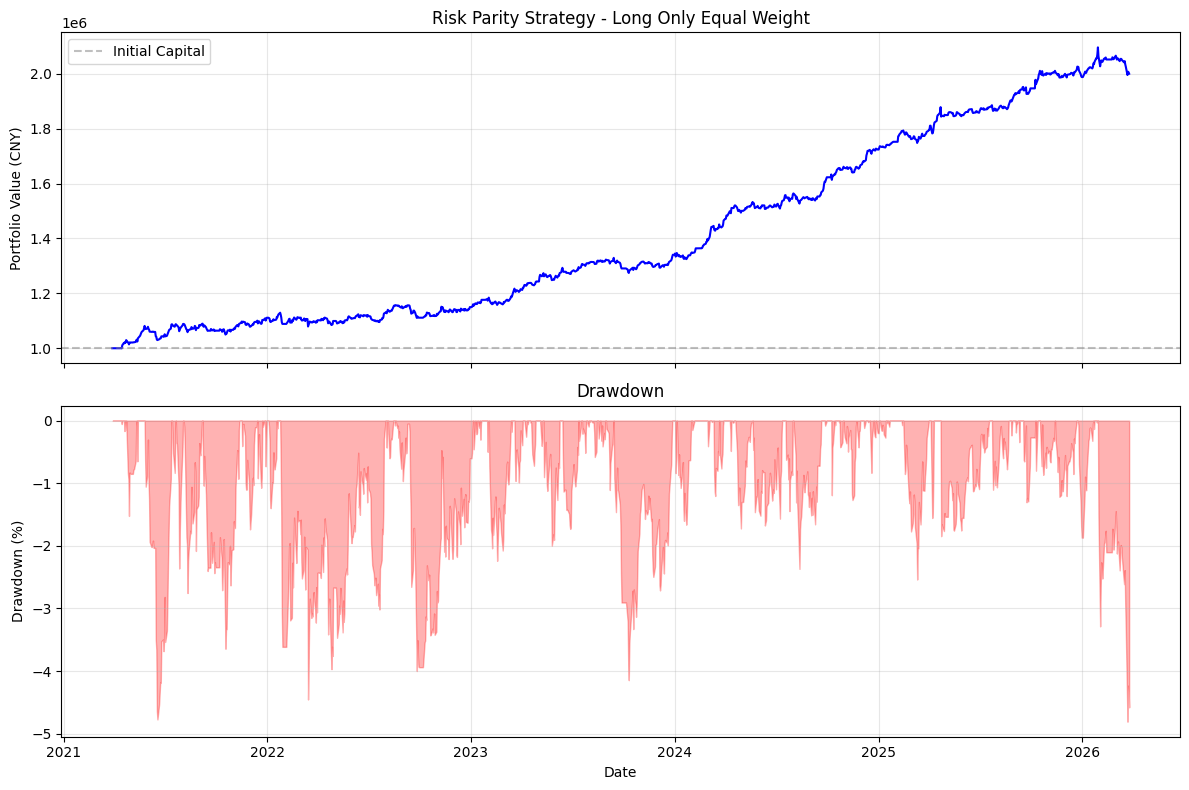

In [11]:
# Plot equity curve and drawdown

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Equity curve
axes[0].plot(equity_curve.index, equity_curve.values, 'b-', linewidth=1.5)
axes[0].set_ylabel('Portfolio Value (CNY)')
axes[0].set_title('Risk Parity Strategy - Rolling Inverse Volatility Weights')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=config.notional_trading_capital, color='gray', linestyle='--', alpha=0.5, label='Initial Capital')
axes[0].legend()

# Drawdown
axes[1].fill_between(drawdown.index, drawdown.values, 0, color='red', alpha=0.3)
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('Date')
axes[1].set_title('Drawdown')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

2026-03-26 21:10:38 DEBUG base_system {'stage': 'accounts', 'instrument_code': '510300.SH'} Calculating pandl for instrument for 510300.SH
2026-03-26 21:10:38 DEBUG base_system {'stage': 'accounts', 'instrument_code': '510300.SH'} Calculating pandl for instrument for 510300.SH
2026-03-26 21:10:38 DEBUG base_system {'stage': 'accounts', 'instrument_code': '518880.SH'} Calculating pandl for instrument for 518880.SH
2026-03-26 21:10:38 DEBUG base_system {'stage': 'accounts', 'instrument_code': '518880.SH'} Calculating pandl for instrument for 518880.SH
2026-03-26 21:10:38 DEBUG base_system {'stage': 'accounts', 'instrument_code': '511260.SH'} Calculating pandl for instrument for 511260.SH
2026-03-26 21:10:38 DEBUG base_system {'stage': 'accounts', 'instrument_code': '511260.SH'} Calculating pandl for instrument for 511260.SH


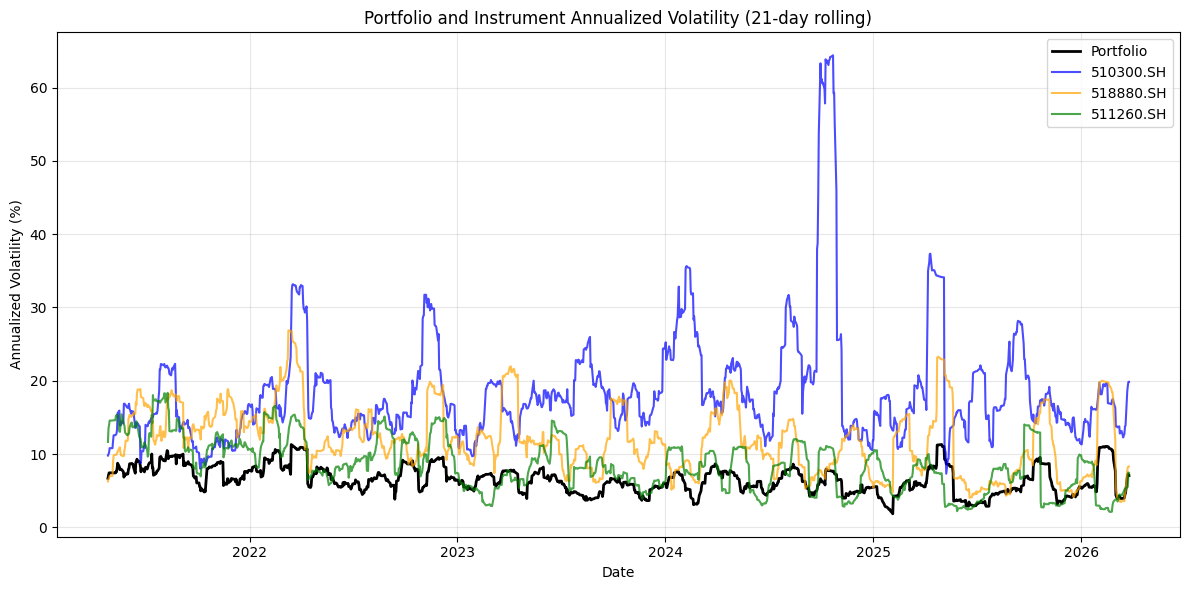

In [13]:
# Plot portfolio and instrument annualized volatility over time

import matplotlib.pyplot as plt

# Calculate rolling volatility for each instrument (21-day window ~ 1 month)
trading_days_per_year = 252
window = 21  # ~1 month of trading days

# Get portfolio equity curve
portfolio_equity = backtest_system.accounts.portfolio().curve() + config.notional_trading_capital

# Calculate portfolio rolling volatility
portfolio_returns = portfolio_equity.pct_change().dropna()
portfolio_rolling_vol = portfolio_returns.rolling(window=window).std() * np.sqrt(trading_days_per_year) * 100

# Calculate instrument rolling volatility
instr_vol_dict = {}
for instr in TARGET_ETFS:
    instr_curve = backtest_system.accounts.pandl_for_instrument(instr).curve()
    instr_capital = config.notional_trading_capital / len(TARGET_ETFS)
    instr_equity = instr_curve + instr_capital
    instr_returns = instr_equity.pct_change().dropna()
    instr_rolling_vol = instr_returns.rolling(window=window).std() * np.sqrt(trading_days_per_year) * 100
    instr_vol_dict[instr] = instr_rolling_vol

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

# Portfolio volatility
ax.plot(portfolio_rolling_vol.index, portfolio_rolling_vol.values, label='Portfolio', linewidth=2, color='black')

# Instrument volatilities
colors = ['blue', 'orange', 'green']
for i, instr in enumerate(TARGET_ETFS):
    ax.plot(instr_vol_dict[instr].index, instr_vol_dict[instr].values, 
             label=instr, linewidth=1.5, color=colors[i], alpha=0.7)

ax.set_ylabel('Annualized Volatility (%)')
ax.set_xlabel('Date')
ax.set_title('Portfolio and Instrument Annualized Volatility (21-day rolling)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Display per-instrument contribution

print("\n--- Per-Instrument Performance ---")

for instr in TARGET_ETFS:
    if instr in backtest_system.get_instrument_list():
        # Get instrument account curve (P&L contribution)
        instr_curve = backtest_system.accounts.pandl_for_instrument(instr).curve()
        
        if len(instr_curve) > 0:
            # P&L curve starts at 0, so calculate return based on allocated capital
            # Equal weights: 1/3 capital per instrument
            instr_capital = config.notional_trading_capital / len(TARGET_ETFS)
            instr_equity = instr_curve + instr_capital
            
            # Calculate total return
            instr_total_return = (instr_equity.iloc[-1] / instr_equity.iloc[0] - 1) * 100
            
            # Calculate years
            instr_years = len(instr_equity) / trading_days_per_year
            
            # Calculate annualized return
            instr_ann_return = ((1 + instr_total_return/100) ** (1/instr_years) - 1) * 100 if instr_years > 0 else 0
            
            # Calculate annualized volatility from equity curve returns
            instr_returns = instr_equity.pct_change().dropna()
            instr_ann_vol = instr_returns.std() * np.sqrt(trading_days_per_year) * 100
            
            # Calculate Sharpe ratio (annualized return / annualized volatility)
            instr_sharpe = instr_ann_return / instr_ann_vol if instr_ann_vol > 0 and not np.isnan(instr_ann_vol) else 0
            
            print(f"\n{instr}:")
            print(f"  Total Return: {instr_total_return:.2f}%")
            print(f"  Annualized Return: {instr_ann_return:.2f}%")
            print(f"  Annualized Vol: {instr_ann_vol:.2f}%")
            print(f"  Sharpe: {instr_sharpe:.2f}")


--- Per-Instrument Performance ---
2026-03-26 21:10:38 DEBUG base_system {'stage': 'accounts', 'instrument_code': '510300.SH'} Calculating pandl for instrument for 510300.SH
2026-03-26 21:10:38 DEBUG base_system {'stage': 'accounts', 'instrument_code': '510300.SH'} Calculating pandl for instrument for 510300.SH

510300.SH:
  Total Return: -7.40%
  Annualized Return: -1.48%
  Annualized Vol: 20.25%
  Sharpe: -0.07
2026-03-26 21:10:38 DEBUG base_system {'stage': 'accounts', 'instrument_code': '518880.SH'} Calculating pandl for instrument for 518880.SH
2026-03-26 21:10:38 DEBUG base_system {'stage': 'accounts', 'instrument_code': '518880.SH'} Calculating pandl for instrument for 518880.SH

518880.SH:
  Total Return: 163.95%
  Annualized Return: 20.63%
  Annualized Vol: 12.62%
  Sharpe: 1.63
2026-03-26 21:10:38 DEBUG base_system {'stage': 'accounts', 'instrument_code': '511260.SH'} Calculating pandl for instrument for 511260.SH
2026-03-26 21:10:38 DEBUG base_system {'stage': 'accounts', '